# 05 — Model Evaluation

Комплексная оценка обученных моделей:
- Оптимальный порог классификации (max F1)
- Confusion matrix при оптимальном пороге
- Калибровка вероятностей (reliability diagram)
- Кривые Лифта и Gain
- Бизнес-метрика при разных порогах
- Анализ ошибок по сегментам клиентов
- Финальная сравнительная таблица

> **Примечание:** предсказания in-sample — модели обучались на этих же данных.  
> Для честного сравнения AUC используй OOF-метрики из ноутбука 04.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src import config
from src.evaluation import find_optimal_threshold, business_metric

COLORS = ['steelblue', 'forestgreen', 'darkorange', 'crimson', 'purple']
MODEL_NAMES = ['logreg', 'rf', 'lgbm', 'catboost', 'ebm']
COST_FN, COST_FP = 1.0, 5.0   # пропущенный дефолт vs отклонённый хороший клиент

print('Ready.')

Ready.


## 1. Загрузка обученных моделей

In [2]:
models = {}
for name in MODEL_NAMES:
    path = config.MODELS_DIR / f'{name}.joblib'
    if not path.exists():
        raise FileNotFoundError(f'Model not found: {path}. Run notebook 04 first.')
    models[name] = joblib.load(path)
    print(f'  [OK] {name:10s}  ({path.stat().st_size / 1024:.0f} KB)')

df_full = pd.read_parquet(config.PROCESSED_FILES['final_train_clean'])
y = df_full[config.TARGET_COL].to_numpy()
X = df_full.drop(columns=[config.TARGET_COL, config.ID_COL])
X_arr = X.to_numpy(dtype=np.float32)

print(f'\nData: {X.shape[0]:,} rows x {X.shape[1]} features | default rate: {y.mean():.2%}')
print('\nGenerating in-sample predictions...')

scores = {}
for name in MODEL_NAMES:
    m = models[name]
    arr = m._scaler.transform(X_arr) if hasattr(m, '_scaler') else X_arr
    scores[name] = m.predict_proba(arr)[:, 1]
    print(f'  {name}: done')

  [OK] logreg      (7 KB)
  [OK] rf          (914762 KB)
  [OK] lgbm        (6795 KB)
  [OK] catboost    (1114 KB)
  [OK] ebm         (2885 KB)

Data: 307,511 rows x 209 features | default rate: 8.07%

Generating in-sample predictions...
  logreg: done
  rf: done
  lgbm: done
  catboost: done
  ebm: done


## 2. Оптимальный порог вместо 0.5

При дисбалансе классов (8% дефолтов) порог 0.5 смещает модель в сторону предсказания нуля.
Подбираем порог, максимизирующий **F-beta** (beta=2) на обучающей выборке — это взвешивает
Recall в два раза выше Precision, отражая банковскую логику: пропустить дефолт (FN) значительно
дороже, чем отказать хорошему клиенту (FP).

In [3]:
print(f'{"Model":<12} {"Thr":>8} {"Fbeta2":>8} {"Prec":>8} {"Recall":>8} {"AUC":>8}')
print('-' * 56)

thresholds = {}
metrics_thr = {}

for name in MODEL_NAMES:
    thr, f_val = find_optimal_threshold(y, scores[name], beta=2.0)
    thresholds[name] = thr
    y_pred = (scores[name] >= thr).astype(int)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    auc  = roc_auc_score(y, scores[name])
    metrics_thr[name] = dict(threshold=thr, f1=f_val, precision=prec, recall=rec, auc=auc)
    print(f'  {name:<10} {thr:>8.4f} {f_val:>8.4f} {prec:>8.4f} {rec:>8.4f} {auc:>8.4f}')

Model             Thr   Fbeta2     Prec   Recall      AUC
--------------------------------------------------------
  logreg       0.5046   0.4373   0.1750   0.6994   0.7731
  rf           0.5045   0.9463   0.8250   0.9824   0.9962
  lgbm         0.5817   0.7487   0.4658   0.8828   0.9637
  catboost     0.5241   0.5164   0.2316   0.7455   0.8477
  ebm          0.0926   0.4648   0.2030   0.6862   0.7986


## 3. Confusion Matrix при оптимальном пороге

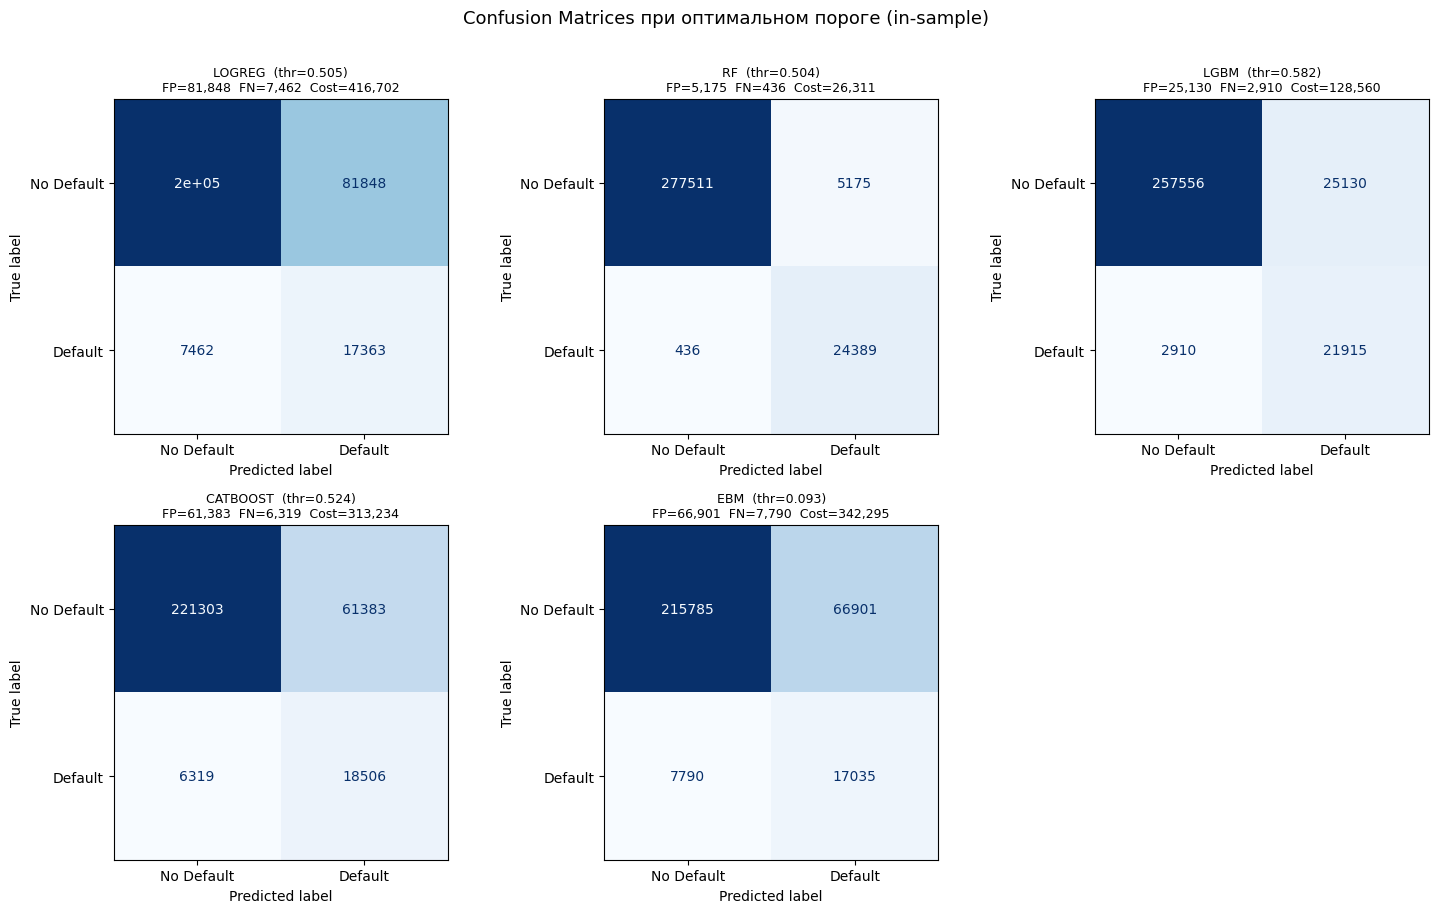

Saved -> reports/eval_confusion_matrices.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
flat = list(axes.flat)

for i, name in enumerate(MODEL_NAMES):
    ax = flat[i]
    thr = thresholds[name]
    y_pred = (scores[name] >= thr).astype(int)
    cm_vals = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm_vals, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    bm = business_metric(y, y_pred, COST_FN, COST_FP)
    fp_n, fn_n, cost_n = bm['fp'], bm['fn'], bm['total_cost']
    ax.set_title(
        f'{name.upper()}  (thr={thr:.3f})\nFP={fp_n:,}  FN={fn_n:,}  Cost={cost_n:,.0f}',
        fontsize=9,
    )

flat[-1].set_visible(False)
plt.suptitle('Confusion Matrices при оптимальном пороге (in-sample)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/eval_confusion_matrices.png')

## 4. Калибровка вероятностей

Reliability diagram: если модель предсказывает P=0.3, то среди таких клиентов ~30% должны оказаться дефолтами.  
Кривая выше диагонали — модель занижает риски; ниже — завышает.

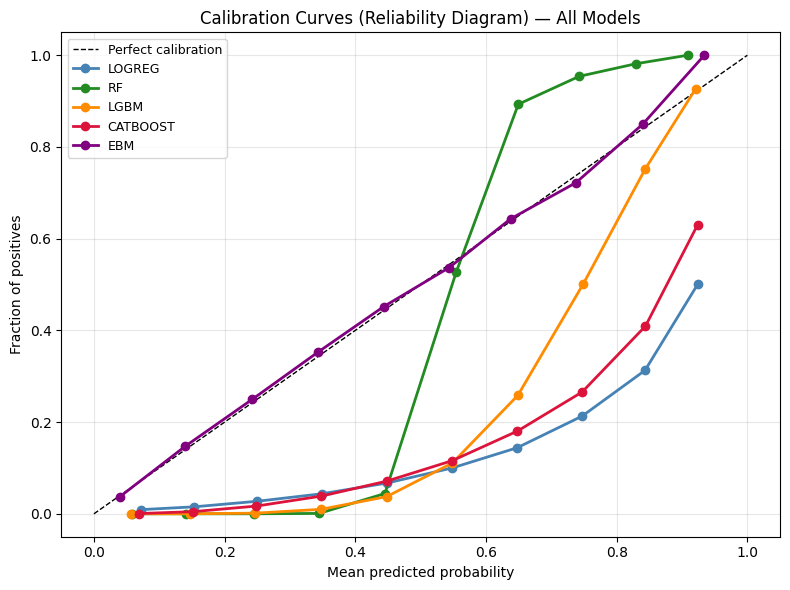

Saved -> reports/eval_calibration.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')

for (name, score), color in zip(scores.items(), COLORS):
    prob_true, prob_pred = calibration_curve(y, score, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', lw=2, color=color, label=name.upper())

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curves (Reliability Diagram) — All Models')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'eval_calibration.png', dpi=150)
plt.show()
print('Saved -> reports/eval_calibration.png')

## 5. Кривая Лифта и Gain

**Lift:** во сколько раз модель лучше случайного выбора при проверке X% клиентов.  
**Gain:** сколько % дефолтов мы выявляем, проверяя X% клиентов (сортировка по убыванию скора).

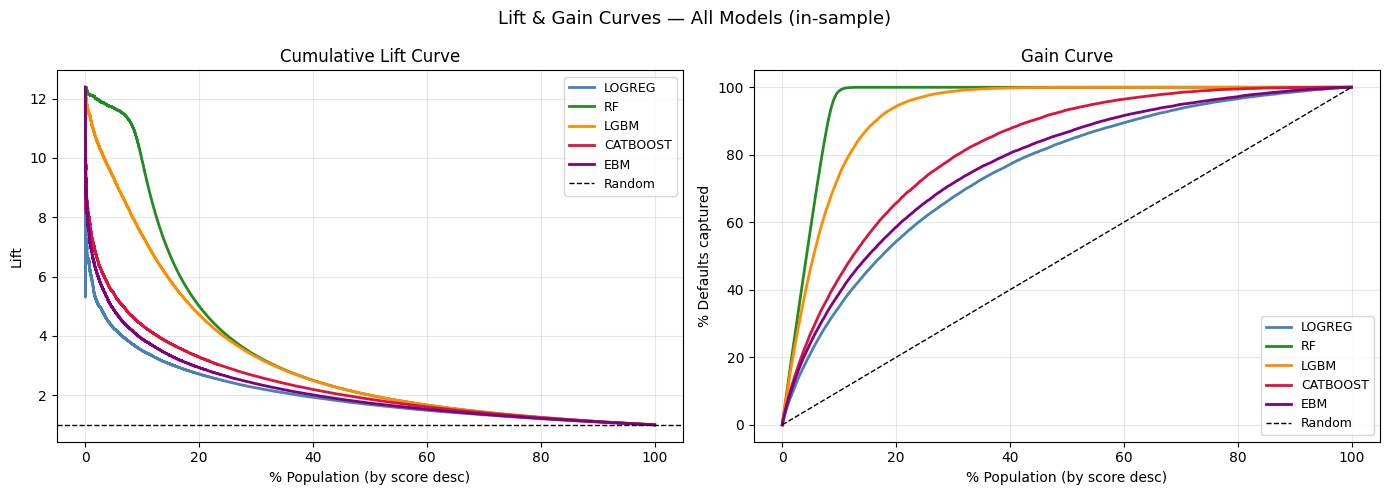

Saved -> reports/eval_lift_gain.png


In [6]:
base_rate = y.mean()
n = len(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, score), color in zip(scores.items(), COLORS):
    sorted_idx = np.argsort(score)[::-1]
    y_sorted = y[sorted_idx]
    cum_pos = np.cumsum(y_sorted)
    pct_pop = np.arange(1, n + 1) / n * 100
    lift = (cum_pos / np.arange(1, n + 1)) / base_rate
    gain = cum_pos / y.sum() * 100
    axes[0].plot(pct_pop, lift, lw=2, color=color, label=name.upper())
    axes[1].plot(pct_pop, gain, lw=2, color=color, label=name.upper())

axes[0].axhline(1.0, color='black', linestyle='--', lw=1, label='Random')
axes[0].set_xlabel('% Population (by score desc)')
axes[0].set_ylabel('Lift')
axes[0].set_title('Cumulative Lift Curve')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot([0, 100], [0, 100], 'k--', lw=1, label='Random')
axes[1].set_xlabel('% Population (by score desc)')
axes[1].set_ylabel('% Defaults captured')
axes[1].set_title('Gain Curve')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Lift & Gain Curves — All Models (in-sample)', fontsize=13)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'eval_lift_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/eval_lift_gain.png')

### Обоснование соотношения COST_FN : COST_FP = 1 : 5

| Тип ошибки | Кто пострадал | Почему 1:5 |
|---|---|---|
| **FN** — пропустили дефолт | Банк несёт убыток в размере всей суммы кредита | Базовая единица потерь |
| **FP** — отклонили хорошего клиента | Банк теряет маржу за весь срок кредита + репутацию | ≈5× сложнее компенсировать |

**Почему FP дороже в 5 раз:**
- Упущенный процентный доход (маржа ~20–25% годовых × срок кредита)
- Потеря клиента и рекомендательного потенциала (CLV)
- Регуляторное давление за отказы: жалобы, проверки, штрафы

> Соотношение 1:5 — типовой диапазон для розничного кредитования (встречается в литературе
> по кредитному скорингу: Hand & Henley 1997, Thomas et al. 2002). В реальной системе
> коэффициенты калибруются на основе фактических P&L данных конкретного портфеля.

**Почему beta=2 при поиске порога:**
F2-score = (1 + 4) × Precision × Recall / (4 × Precision + Recall) — даёт Recall вес
в два раза выше Precision, что соответствует приоритету выявления дефолтов.

## 6. Бизнес-метрика при разных порогах

Стоимостная модель ошибок:
- **FN (False Negative)** — пропустили дефолт, банк теряет сумму кредита → `cost_fn = 1`
- **FP (False Positive)** — отклонили хорошего клиента, потеряли маржу → `cost_fp = 5`

Точки на кривой — оптимальный F1-порог. Вертикальная линия — стандартный порог 0.5.

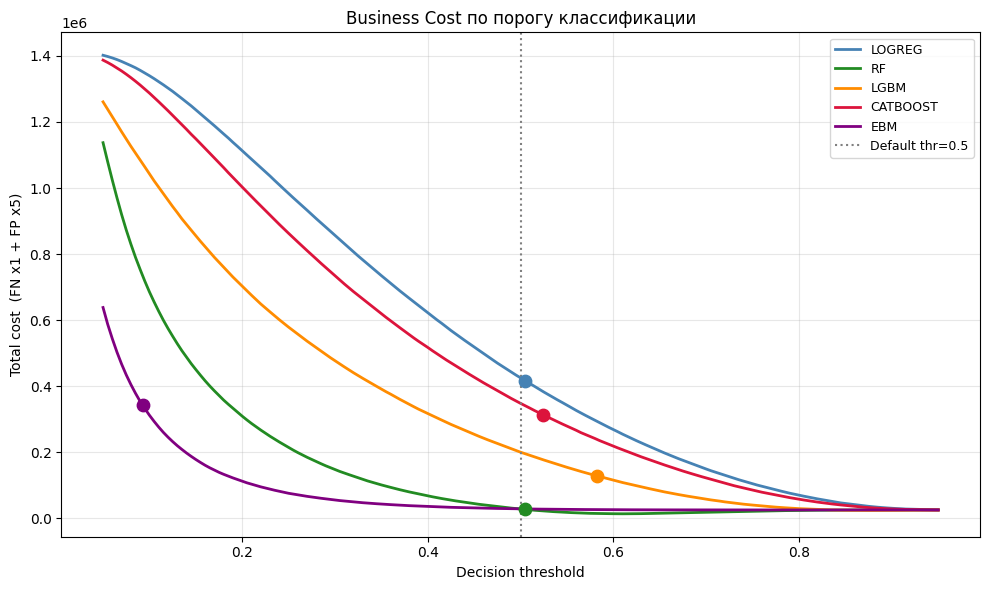

Saved -> reports/eval_business_cost.png

Model            Cost@0.5     Cost@opt    Savings  Thr_opt
  logreg          424,796      416,702      8,094   0.5046
  rf               27,596       26,311      1,285   0.5045
  lgbm            199,679      128,560     71,119   0.5817
  catboost        347,532      313,234     34,298   0.5241
  ebm              28,159      342,295   -314,136   0.0926


In [7]:
sweep = np.linspace(0.05, 0.95, 181)

fig, ax = plt.subplots(figsize=(10, 6))

for (name, score), color in zip(scores.items(), COLORS):
    costs = [
        business_metric(y, (score >= t).astype(int), COST_FN, COST_FP)['total_cost']
        for t in sweep
    ]
    ax.plot(sweep, costs, lw=2, color=color, label=name.upper())
    opt_t = thresholds[name]
    opt_c = business_metric(y, (score >= opt_t).astype(int), COST_FN, COST_FP)['total_cost']
    ax.scatter([opt_t], [opt_c], color=color, s=80, zorder=5)

ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Default thr=0.5')
ax.set_xlabel('Decision threshold')
ax.set_ylabel(f'Total cost  (FN x{COST_FN:.0f} + FP x{COST_FP:.0f})')
ax.set_title('Business Cost по порогу классификации')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'eval_business_cost.png', dpi=150)
plt.show()
print('Saved -> reports/eval_business_cost.png')

print(f'\n{"Model":<12} {"Cost@0.5":>12} {"Cost@opt":>12} {"Savings":>10} {"Thr_opt":>8}')
for name, score in scores.items():
    c05  = business_metric(y, (score >= 0.5).astype(int), COST_FN, COST_FP)['total_cost']
    opt_t = thresholds[name]
    copt = business_metric(y, (score >= opt_t).astype(int), COST_FN, COST_FP)['total_cost']
    print(f'  {name:<10} {c05:>12,.0f} {copt:>12,.0f} {c05 - copt:>10,.0f} {opt_t:>8.4f}')

## 7. Анализ ошибок по сегментам клиентов

Используем лучшую модель по AUC. Анализируем:
- **Возрастная группа** (`DAYS_BIRTH`)
- **Квартиль дохода** (`AMT_INCOME_TOTAL`)
- **Тип кредита** (`NAME_CONTRACT_TYPE_Revolving loans`)

In [8]:
best_name = max(metrics_thr, key=lambda n: metrics_thr[n]['auc'])
best_thr  = thresholds[best_name]
best_score = scores[best_name]
y_pred_best = (best_score >= best_thr).astype(int)
print(f'Лучшая модель по AUC: {best_name.upper()}  (AUC={metrics_thr[best_name]["auc"]:.4f})')

seg = pd.DataFrame({
    'TARGET':           y,
    'y_score':          best_score,
    'y_pred':           y_pred_best,
    'fn':               ((y == 1) & (y_pred_best == 0)).astype(int),
    'fp':               ((y == 0) & (y_pred_best == 1)).astype(int),
    'DAYS_BIRTH':       df_full['DAYS_BIRTH'].to_numpy(),
    'AMT_INCOME_TOTAL': df_full['AMT_INCOME_TOTAL'].to_numpy(),
})

seg['AGE'] = (-seg['DAYS_BIRTH'] / 365).astype(int)
seg['AGE_GROUP'] = pd.cut(
    seg['AGE'], bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '30-40', '40-50', '50-60', '60+'],
)
seg['INCOME_QUARTILE'] = pd.qcut(
    seg['AMT_INCOME_TOTAL'], q=4,
    labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'],
    duplicates='drop',
)
contract_col = 'NAME_CONTRACT_TYPE_Revolving loans'
seg['CONTRACT_TYPE'] = (
    df_full[contract_col].map({1: 'Revolving', 0: 'Cash loans'})
    if contract_col in df_full.columns else 'Cash loans'
)

def seg_table(df, col):
    return (
        df.groupby(col, observed=True)
        .agg(n=('TARGET', 'count'),
             default_rate=('TARGET', 'mean'),
             fn_pct=('fn', 'mean'),
             fp_pct=('fp', 'mean'))
        .assign(
            default_rate=lambda d: d['default_rate'].round(4),
            fn_pct=lambda d: (d['fn_pct'] * 100).round(2),
            fp_pct=lambda d: (d['fp_pct'] * 100).round(2),
        )
    )

age_seg = seg_table(seg, 'AGE_GROUP')
inc_seg = seg_table(seg, 'INCOME_QUARTILE')
con_seg = seg_table(seg, 'CONTRACT_TYPE')

print('\nВозраст:')
print(age_seg.to_string())
print('\nДоход (квартили):')
print(inc_seg.to_string())
print('\nТип кредита:')
print(con_seg.to_string())

Лучшая модель по AUC: RF  (AUC=0.9962)

Возраст:
               n  default_rate  fn_pct  fp_pct
AGE_GROUP                                     
18-30      52806        0.1140    0.04    4.74
30-40      83117        0.0929    0.10    1.87
40-50      74401        0.0755    0.12    1.05
50-60      67819        0.0593    0.22    0.48
60+        29368        0.0492    0.31    0.04

Доход (квартили):
                      n  default_rate  fn_pct  fp_pct
INCOME_QUARTILE                                      
Q1 (low)         100578        0.0839    0.17    2.29
Q2                53182        0.0853    0.18    2.20
Q3                82213        0.0840    0.14    1.59
Q4 (high)         71538        0.0691    0.08    0.55

Тип кредита:
                    n  default_rate  fn_pct  fp_pct
CONTRACT_TYPE                                      
Cash loans     278232        0.0835    0.14    1.79
Revolving       29279        0.0548    0.16    0.62


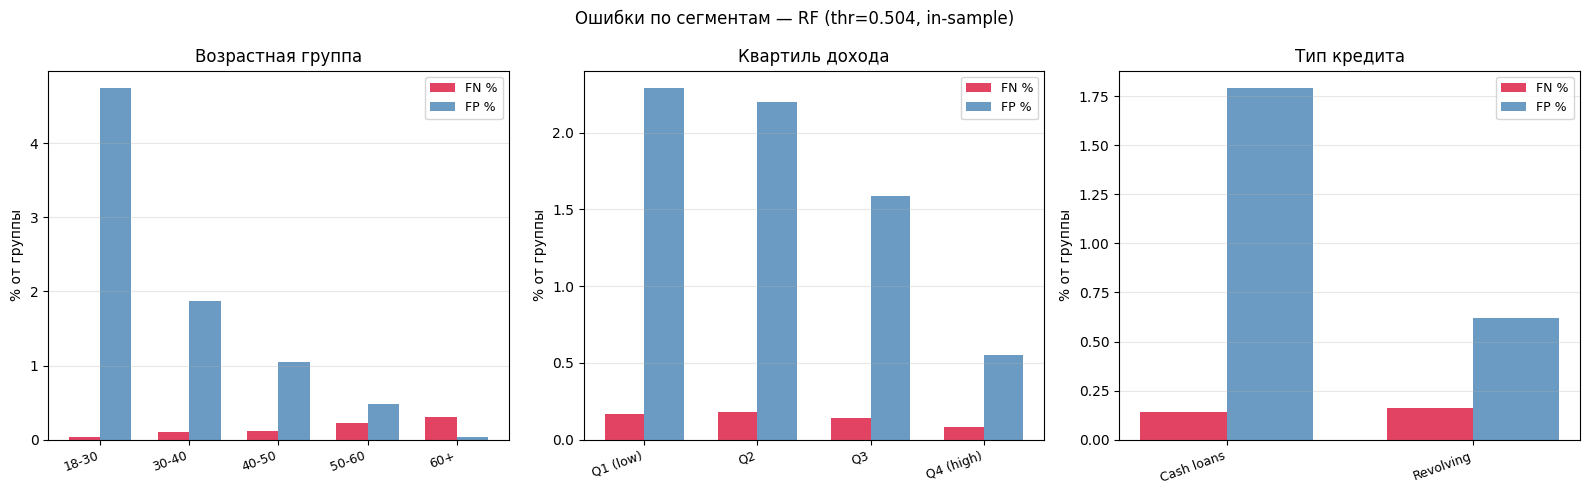

Saved -> reports/eval_segment_errors.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seg_items = [
    (age_seg, 'Возрастная группа'),
    (inc_seg, 'Квартиль дохода'),
    (con_seg, 'Тип кредита'),
]

for ax, (seg_df, title) in zip(axes, seg_items):
    x = np.arange(len(seg_df))
    w = 0.35
    ax.bar(x - w / 2, seg_df['fn_pct'], w, label='FN %', color='crimson',   alpha=0.8)
    ax.bar(x + w / 2, seg_df['fp_pct'], w, label='FP %', color='steelblue', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(seg_df.index.astype(str), rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('% от группы')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    f'Ошибки по сегментам — {best_name.upper()} (thr={best_thr:.3f}, in-sample)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'eval_segment_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/eval_segment_errors.png')

## 8. Финальная сравнительная таблица

In [10]:
rows = []
for name in MODEL_NAMES:
    m = metrics_thr[name]
    thr = thresholds[name]
    bm_opt  = business_metric(y, (scores[name] >= thr).astype(int), COST_FN, COST_FP)
    bm_half = business_metric(y, (scores[name] >= 0.5).astype(int), COST_FN, COST_FP)
    rows.append({
        'Model':         name.upper(),
        'AUC':           round(m['auc'], 4),
        'Opt Threshold': round(thr, 4),
        'F1 @ opt':      round(m['f1'], 4),
        'Precision':     round(m['precision'], 4),
        'Recall':        round(m['recall'], 4),
        'Cost @ opt':    int(bm_opt['total_cost']),
        'Cost @ 0.5':    int(bm_half['total_cost']),
        'Savings':       int(bm_half['total_cost'] - bm_opt['total_cost']),
        'FP':            bm_opt['fp'],
        'FN':            bm_opt['fn'],
    })

final_table = (
    pd.DataFrame(rows)
    .sort_values('AUC', ascending=False)
    .reset_index(drop=True)
)

final_table.style \
    .background_gradient(subset=['AUC'],        cmap='RdYlGn') \
    .background_gradient(subset=['F1 @ opt'],   cmap='RdYlGn') \
    .background_gradient(subset=['Cost @ opt'], cmap='RdYlGn_r') \
    .background_gradient(subset=['Savings'],    cmap='RdYlGn') \
    .format({'Cost @ opt': '{:,}', 'Cost @ 0.5': '{:,}', 'Savings': '{:,}'})

,Model,AUC,Opt Threshold,F1 @ opt,Precision,Recall,Cost @ opt,Cost @ 0.5,Savings,FP,FN
0,RF,0.996200,0.504500,0.946300,0.825000,0.982400,"26,311","27,596","1,285",5175,436
1,LGBM,0.963700,0.581700,0.748700,0.465800,0.882800,"128,560","199,679","71,119",25130,2910
2,CATBOOST,0.847700,0.524100,0.516400,0.231600,0.745500,"313,234","347,532","34,298",61383,6319
3,EBM,0.798600,0.092600,0.464800,0.203000,0.686200,"342,295","28,159","-314,136",66901,7790
4,LOGREG,0.773100,0.504600,0.437300,0.175000,0.699400,"416,702","424,796","8,094",81848,7462


In [11]:
best_by_auc  = final_table.iloc[0]['Model']
best_by_cost = final_table.loc[final_table['Cost @ opt'].idxmin(), 'Model']

print('=' * 55)
print('ИТОГ')
print('=' * 55)
print(f'\nЛучшая по AUC:              {best_by_auc}')
print(f'Лучшая по бизнес-стоимости: {best_by_cost}')
print('\nПримечание: метрики вычислены на обучающей выборке (in-sample).')
print('Честный AUC — OOF-оценка из ноутбука 04 (CV на 307 511 строках).')
print('Пороги подобраны по F2 (beta=2) — Recall приоритетен над Precision.')

print('\nСохранённые артефакты:')
for fname in [
    'eval_confusion_matrices.png',
    'eval_calibration.png',
    'eval_lift_gain.png',
    'eval_business_cost.png',
    'eval_segment_errors.png',
]:
    p = config.REPORTS_DIR / fname
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] reports/{fname}')

ИТОГ

Лучшая по AUC:              RF
Лучшая по бизнес-стоимости: RF

Примечание: метрики вычислены на обучающей выборке (in-sample).
Честный AUC — OOF-оценка из ноутбука 04 (CV на 307 511 строках).
Пороги подобраны по F2 (beta=2) — Recall приоритетен над Precision.

Сохранённые артефакты:
  [OK] reports/eval_confusion_matrices.png
  [OK] reports/eval_calibration.png
  [OK] reports/eval_lift_gain.png
  [OK] reports/eval_business_cost.png
  [OK] reports/eval_segment_errors.png
